# Accessing MLB data

## Importing packages

In [42]:
import requests
import pandas as pd
import datetime
import pytz

## Kalshi access w/o auth API

In [6]:
base = "https://external-api.kalshi.com/trade-api/v2"

# getting events in the sports category
resp = requests.get(f"{base}/events", params={
    "category": "sports",
    "status": "open",
    "limit": 200
})
events = resp.json()["events"]

# baseball tickers
baseball = [e for e in events if any(
    kw in e["title"].lower() for kw in ["baseball", "game", "win"]
)]

for e in baseball:
    print(e["event_ticker"], "|", e["title"])

KXBRUVSEAT-35 | Will Andrew Tate's party win a seat in the next UK election?
KXPRESPARTY-2032 | Which party will win the 2032 Presidential Election?
KXCANADACUP-30 | Canadian Team to Win the Stanley Cup® Before the 2031 Season
KXNBASEATTLE-30 | Will a Seattle Pro Basketball team play a game before 2030?
KXUKPARTY-29 | Which party will win the next UK general election?
POWER-28 | 2028: Who will win the Presidency, House, and Senate?
CONTROLS-2028 | 2028 Senate winner
CONTROLH-2028 | 2028 House winner
KXPRESPERSON-28 | 2028 U.S. Presidential Election winner?
KXPRESPARTY-2028 | 2028 Presidential Election winner? (Party)
GOVPARTYDE-28 | Delaware governor winner? (2028)
GOVPARTYWV-28 | West Virginia governor winner? (2028)
GOVPARTYMO-28 | Missouri governor winner? (2028)
GOVPARTYIN-28 | Indiana Governor winner? (2028)
GOVPARTYNH-28 | New Hampshire Governor winner?
SENATEIN-28 | Indiana Senate winner? (2028)
GOVPARTYVT-28 | Vermont Governor Winner? (2028)
SENATEWI-28 | Wisconsin Senate winne

## Trying an example w/ known baseball ticker NOT WORKING

In [7]:
event_ticker = "KXMLBGAME-26MAY151915NYYNYM-NYY"  # example
resp = requests.get(f"{base}/markets", params={"event_ticker": event_ticker})
markets = resp.json()["markets"]

for m in markets:
    yes_price = m["yes_bid"]  # e.g., 0.65 = 65% implied probability
    print(f"{m['ticker']}: {m['title']} | Yes: {yes_price}")

## Converting Kalshi prediction to an implied odd

In [44]:
def odds(prob):
    """Convert Kalshi implied probability to American moneyline odds."""
    if prob >= 0.5:
        return round(-prob / (1 - prob) * 100)
    else:
        return round((1 - prob) / prob * 100)

# Example: Kalshi shows 0.65 (65%) for Team A
print(odds(0.65))  # → -186 (Team A is -186 favorite)
print(odds(0.35))  # → +186 (Team B is +186 dog)

-186
186


## Looking at settled markets

In [ ]:
all_markets = []
cursor = None

while True:
    params = {
        "series_ticker": "KXMLBGAME", 
        "status": "settled",
        "limit": 200
    }
    if cursor:
        params["cursor"] = cursor

    resp = requests.get(f"{base}/markets", params=params).json()
    all_markets.extend(resp["markets"])
    
    cursor = resp.get("cursor")
    if not cursor:
        break



In [10]:
all_markets

[{'can_close_early': True,
  'close_time': '2026-05-20T23:00:40Z',
  'created_time': '2026-05-17T20:15:58.777216Z',
  'custom_strike': {'baseball_team': '00ca8318-b0fe-45c4-82c7-f43901a96114'},
  'early_close_condition': 'This market will close and expire after a winner is declared.',
  'event_ticker': 'KXMLBGAME-26MAY201610CWSSEA',
  'expected_expiration_time': '2026-05-20T23:10:00Z',
  'expiration_time': '2026-05-23T20:10:00Z',
  'expiration_value': 'Seattle',
  'fractional_trading_enabled': True,
  'last_price_dollars': '0.9900',
  'latest_expiration_time': '2026-05-23T20:10:00Z',
  'liquidity_dollars': '0.0000',
  'market_type': 'binary',
  'no_ask_dollars': '0.0100',
  'no_bid_dollars': '0.0000',
  'no_sub_title': 'Seattle',
  'notional_value_dollars': '1.0000',
  'occurrence_datetime': '2026-05-20T23:10:00Z',
  'open_interest_fp': '1434620.25',
  'open_time': '2026-05-17T20:25:00Z',
  'previous_price_dollars': '0.5700',
  'previous_yes_ask_dollars': '0.5800',
  'previous_yes_bid_

## Unix timestamp for start_ts

In [11]:
from datetime import datetime
iso_time = "2026-04-07T17:30:50Z"

game_dt = datetime.fromisoformat(
    iso_time.replace("Z", "+00:00")
)

start_ts = int(game_dt.timestamp())

print(start_ts)
# start 1775524910
# end 1775611310
# 1 hr before game ex 1775583050


1775583050


In [ ]:
from datetime import timedelta
def subtract_24h_iso(iso_time: str) -> str:
    dt = datetime.fromisoformat(iso_time.replace("Z", "+00:00"))
    
    prev_dt = dt - timedelta(hours=24)

    return prev_dt.strftime("%Y-%m-%dT%H:%M:%SZ")

In [13]:
subtract_24h_iso("2026-04-08T01:21:50Z")

'2026-04-07T01:21:50Z'

In [17]:
# get_opening_price("KXMLBGAME-26APR071845MILBOS-BOS", "2026-04-08T01:21:50Z")

## Sanity check using Get Market Candlesticks (live dataset)

In [18]:
series_ticker = "KXMLBGAME"
market_ticker = "KXMLBGAME-26APR071845MILBOS-BOS"

url = (
    f"https://external-api.kalshi.com/trade-api/v2/"
    f"series/{series_ticker}/markets/{market_ticker}/candlesticks"
)

params = {
    "start_ts": 1775583050,
    "end_ts": 1775611310,
    "period_interval": 60,
    "include_latest_before_start": "true"
}

response = requests.get(url, params=params)

print(response.status_code)

data = response.json()


200


In [21]:
candles = data["candlesticks"]

df = pd.json_normalize(candles)

print(df.head())

   end_period_ts open_interest_fp volume_fp price.close_dollars  \
0     1775584800         22550.00   2171.00              0.5900   
1     1775588400         28620.00   6136.00              0.5900   
2     1775592000         38630.00  10011.00              0.5900   
3     1775595600         55110.00  16560.00              0.5900   
4     1775599200         73171.00  18192.00              0.6000   

  price.high_dollars price.low_dollars price.mean_dollars price.open_dollars  \
0             0.5900            0.5800             0.5898             0.5900   
1             0.5900            0.5800             0.5899             0.5900   
2             0.5900            0.5800             0.5899             0.5900   
3             0.5900            0.5800             0.5896             0.5900   
4             0.6000            0.5800             0.5963             0.5900   

  price.previous_dollars yes_ask.close_dollars yes_ask.high_dollars  \
0                 0.5900                0.590

In [43]:
import datetime
from dateutil import parser
from datetime import timezone

time_str = "If Boston wins the Milwaukee vs Boston professional baseball game originally scheduled for Apr 7, 2026 at 6:45 PM EDT"

cleaned = time_str.replace("EDT", "")

dt = parser.parse(cleaned, fuzzy=True)

dt = dt.replace(tzinfo=timezone.utc)
            

dt_start = dt.replace(minute=0, second=0, microsecond=0) - datetime.timedelta(hours=1)
start_ts = int(dt_start.timestamp())
            
dt_end = dt_start + datetime.timedelta(hours=8)
end_ts = int(dt_end.timestamp())

print(start_ts)
print(end_ts)
# just a test

1775581200
1775610000


In [ ]:
def transform_markets(all_markets):
    new_markets = []
               
    for market in all_markets:
        rules_primary = market.get('rules_primary', '')
        ticker = market.get('ticker', '')
        
        try:
            time_str = rules_primary

            cleaned = time_str.replace("EDT", "")

            dt = parser.parse(cleaned, fuzzy=True)

            dt = dt.replace(tzinfo=timezone.utc)
            

            dt_start = dt.replace(minute=0, second=0, microsecond=0) - datetime.timedelta(hours=1)
            start_ts = int(dt_start.timestamp())
            

            dt_end = dt_start + datetime.timedelta(hours=12)
            end_ts = int(dt_end.timestamp())

            
            new_dict = {
                'start_ts': start_ts,
                'end_ts': end_ts,
                'series_ticker': 'KXMLBGAME',
                'market_ticker': ticker,
                'period_interval': 60,
                'included_latest_before_start': "true"
            }
            
            new_markets.append(new_dict)
            
        except Exception as e:
            print(f"Error processing {ticker} with time string '{rules_primary}': {e}")
            
    return new_markets

In [25]:
new_markets = transform_markets(all_markets)
subset = new_markets[:3]
new_markets

[{'start_ts': 1779289200,
  'end_ts': 1779332400,
  'series_ticker': 'KXMLBGAME',
  'market_ticker': 'KXMLBGAME-26MAY201610CWSSEA-SEA',
  'period_interval': 60,
  'included_latest_before_start': 'true'},
 {'start_ts': 1779289200,
  'end_ts': 1779332400,
  'series_ticker': 'KXMLBGAME',
  'market_ticker': 'KXMLBGAME-26MAY201610CWSSEA-CWS',
  'period_interval': 60,
  'included_latest_before_start': 'true'},
 {'start_ts': 1779285600,
  'end_ts': 1779328800,
  'series_ticker': 'KXMLBGAME',
  'market_ticker': 'KXMLBGAME-26MAY201540SFAZ-SF',
  'period_interval': 60,
  'included_latest_before_start': 'true'},
 {'start_ts': 1779285600,
  'end_ts': 1779328800,
  'series_ticker': 'KXMLBGAME',
  'market_ticker': 'KXMLBGAME-26MAY201540SFAZ-AZ',
  'period_interval': 60,
  'included_latest_before_start': 'true'},
 {'start_ts': 1779285600,
  'end_ts': 1779328800,
  'series_ticker': 'KXMLBGAME',
  'market_ticker': 'KXMLBGAME-26MAY201510TEXCOL-TEX',
  'period_interval': 60,
  'included_latest_before_sta

In [ ]:
import requests
import pandas as pd
import time

def fetch_all_market_candlesticks(new_markets):
    master_candlesticks_list = []
    
    for market_params in new_markets:
        series_ticker = market_params['series_ticker']
        market_ticker = market_params['market_ticker']
        
        url = (
            f"https://external-api.kalshi.com/trade-api/v2/"
            f"series/{series_ticker}/markets/{market_ticker}/candlesticks"
        )
        
        params = {
            "start_ts": market_params['start_ts'],
            "end_ts": market_params['end_ts'],
            "period_interval": market_params['period_interval'],
            "include_latest_before_start": "true"
        }
        
        try:
            response = requests.get(url, params=params)
            
            response.raise_for_status() 
            
            data = response.json()
            candles = data.get("candlesticks", [])
            

            for candle in candles:
                candle['market_ticker'] = market_ticker
                price_data = candle.get('price', {})
                yesAsk = candle.get('yes_ask', {})
                yesBid = candle.get('yes_bid', {})

                
                mean_dlrs = price_data.get('mean_dollars')
                prev_dlrs = price_data.get('previous_dollars')
                open_dlrs = price_data.get('open_dollars')
                close_dlrs = price_data.get('close_dollars')
                high_dlrs = price_data.get('high_dollars')
                low_dlrs = price_data.get('low_dollars')

                
                candle['mean_dollars'] = float(mean_dlrs) if mean_dlrs is not None else None
                candle['previous_dollars'] = float(prev_dlrs) if prev_dlrs is not None else None
                candle['open_dollars'] = float(open_dlrs) if open_dlrs is not None else None
                candle['close_dollars'] = float(close_dlrs) if close_dlrs is not None else None
                candle['high_dollars'] = float(high_dlrs) if high_dlrs is not None else None
                candle['low_dollars'] = float(low_dlrs) if low_dlrs is not None else None

                ask_close = yesAsk.get('close_dollars')
                ask_high = yesAsk.get('high_dollars')
                ask_low = yesAsk.get('low_dollars')
                ask_open = yesAsk.get('open_dollars')

                candle['ask_close_dollars'] = float(ask_close) if ask_close is not None else None
                candle['ask_high_dollars'] = float(ask_high) if ask_high is not None else None
                candle['ask_low_dollars'] = float(ask_low) if ask_low is not None else None
                candle['ask_open_dollars'] = float(ask_open) if ask_open is not None else None

                # 5. yes bid
                bid_close = yesBid.get('close_dollars')
                bid_high = yesBid.get('high_dollars')
                bid_low = yesBid.get('low_dollars')
                bid_open = yesBid.get('open_dollars')

                candle['bid_close_dollars'] = float(bid_close) if bid_close is not None else None
                candle['bid_high_dollars'] = float(bid_high) if bid_high is not None else None
                candle['bid_low_dollars'] = float(bid_low) if bid_low is not None else None
                candle['bid_open_dollars'] = float(bid_open) if bid_open is not None else None
                

                master_candlesticks_list.append(candle)


                
        except requests.exceptions.RequestException as e:
            print(f"Error fetching data for {market_ticker}: {e}")
            
        time.sleep(0.1)
        
    df = pd.DataFrame(master_candlesticks_list)
    
    if not df.empty:
        front_cols = (
            ['market_ticker', 
            'end_period_ts', 
            'mean_dollars', 
            'previous_dollars', 
            'open_interest_fp', 
            'volume_fp', 
            'open_dollars',
            'close_dollars',
            'high_dollars',
            'low_dollars',
            'ask_close_dollars',
            'bid_close_dollars',
            'ask_high_dollars',
            'bid_high_dollars',
            'ask_low_dollars',
            'bid_low_dollars',
            'ask_open_dollars',
            'bid_open_dollars']
        )
        # Gather the rest of the columns
        back_cols = [col for col in df.columns if col not in front_cols]
        df = df[front_cols + back_cols]
        
    return df


In [38]:
live_dataFinal = fetch_all_market_candlesticks(new_markets)

In [ ]:
# As of May 20, 2026 (goes back 3 months)
live_dataFinal.to_csv("kalshiBaseballLiveData.csv")

In [41]:
len(live_dataFinal)

14564

In [34]:
live_data2 = fetch_all_market_candlesticks_fully_unpacked(subset)
live_data2.head()

,market_ticker,end_period_ts,open_interest_fp,volume_fp,price.close_dollars,price.high_dollars,price.low_dollars,price.mean_dollars,price.open_dollars,price.previous_dollars,yes_ask.close_dollars,yes_ask.high_dollars,yes_ask.low_dollars,yes_ask.open_dollars,yes_bid.close_dollars,yes_bid.high_dollars,yes_bid.low_dollars,yes_bid.open_dollars
0,KXMLBGAME-26MAY201610CWSSEA-SEA,1779289200,22666.27,6517.19,0.58,0.58,0.57,0.5800,0.58,0.58,0.58,0.58,0.58,0.58,0.57,0.57,0.57,0.57
1,KXMLBGAME-26MAY201610CWSSEA-SEA,1779292800,37200.86,14534.59,0.58,0.58,0.57,0.5800,0.58,0.58,0.58,0.58,0.58,0.58,0.57,0.57,0.57,0.57
2,KXMLBGAME-26MAY201610CWSSEA-SEA,1779296400,42102.32,4942.59,0.58,0.58,0.57,0.5799,0.58,0.58,0.58,0.58,0.58,0.58,0.57,0.57,0.57,0.57
3,KXMLBGAME-26MAY201610CWSSEA-SEA,1779300000,48551.63,6728.69,0.58,0.58,0.57,0.5799,0.58,0.58,0.58,0.58,0.58,0.58,0.57,0.57,0.57,0.57
4,KXMLBGAME-26MAY201610CWSSEA-SEA,1779303600,73184.68,24647.46,0.57,0.58,0.56,0.5741,0.58,0.58,0.58,0.58,0.57,0.58,0.57,0.57,0.56,0.57


In [35]:
live_data = fetch_all_market_candlesticks(subset)
live_data.to_csv("kalshiDataTest.csv")
live_data.head()

,market_ticker,end_period_ts,mean_dollars,previous_dollars,open_interest_fp,volume_fp,open_dollars,close_dollars,high_dollars,low_dollars,...,bid_close_dollars,ask_high_dollars,bid_high_dollars,ask_low_dollars,bid_low_dollars,ask_open_dollars,bid_open_dollars,price,yes_ask,yes_bid
0,KXMLBGAME-26MAY201610CWSSEA-SEA,1779289200,0.5800,0.58,22666.27,6517.19,0.58,0.58,0.58,0.57,...,0.57,0.58,0.57,0.58,0.57,0.58,0.57,"{'close_dollars': '0.5800', 'high_dollars': '0...","{'close_dollars': '0.5800', 'high_dollars': '0...","{'close_dollars': '0.5700', 'high_dollars': '0..."
1,KXMLBGAME-26MAY201610CWSSEA-SEA,1779292800,0.5800,0.58,37200.86,14534.59,0.58,0.58,0.58,0.57,...,0.57,0.58,0.57,0.58,0.57,0.58,0.57,"{'close_dollars': '0.5800', 'high_dollars': '0...","{'close_dollars': '0.5800', 'high_dollars': '0...","{'close_dollars': '0.5700', 'high_dollars': '0..."
2,KXMLBGAME-26MAY201610CWSSEA-SEA,1779296400,0.5799,0.58,42102.32,4942.59,0.58,0.58,0.58,0.57,...,0.57,0.58,0.57,0.58,0.57,0.58,0.57,"{'close_dollars': '0.5800', 'high_dollars': '0...","{'close_dollars': '0.5800', 'high_dollars': '0...","{'close_dollars': '0.5700', 'high_dollars': '0..."
3,KXMLBGAME-26MAY201610CWSSEA-SEA,1779300000,0.5799,0.58,48551.63,6728.69,0.58,0.58,0.58,0.57,...,0.57,0.58,0.57,0.58,0.57,0.58,0.57,"{'close_dollars': '0.5800', 'high_dollars': '0...","{'close_dollars': '0.5800', 'high_dollars': '0...","{'close_dollars': '0.5700', 'high_dollars': '0..."
4,KXMLBGAME-26MAY201610CWSSEA-SEA,1779303600,0.5741,0.58,73184.68,24647.46,0.58,0.57,0.58,0.56,...,0.57,0.58,0.57,0.57,0.56,0.58,0.57,"{'close_dollars': '0.5700', 'high_dollars': '0...","{'close_dollars': '0.5800', 'high_dollars': '0...","{'close_dollars': '0.5700', 'high_dollars': '0..."


In [36]:
test01 = live_data[:10]


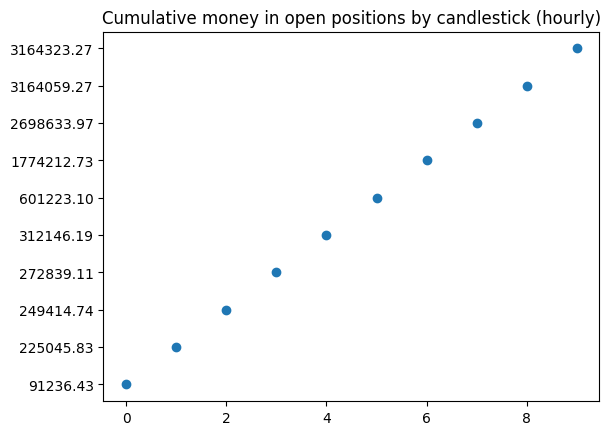

In [ ]:

plt.scatter(test01.index, test01['open_interest_fp'])
plt.title("Cumulative money in open positions by candlestick (hourly)")
plt.show()

This makes sense because open_interest should be total money (in open positions) so it will always be increasing as more people open contracts. It will never decrease because the contracts are closed once the game ends. 

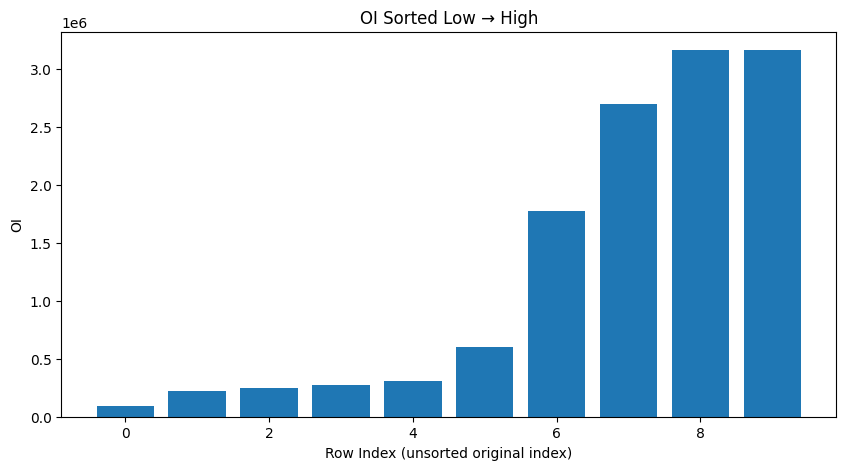

In [146]:
test02 = test01

test02["open_interest_fp"] = pd.to_numeric(test02["open_interest_fp"])
test02_sorted = test02.sort_values("open_interest_fp", ascending=True)

plt.figure(figsize=(10, 5))
plt.bar(test02_sorted.index, test02_sorted["open_interest_fp"])

plt.xlabel("Row Index (unsorted original index)")
plt.ylabel("OI")
plt.title("OI Sorted Low → High")

plt.show()

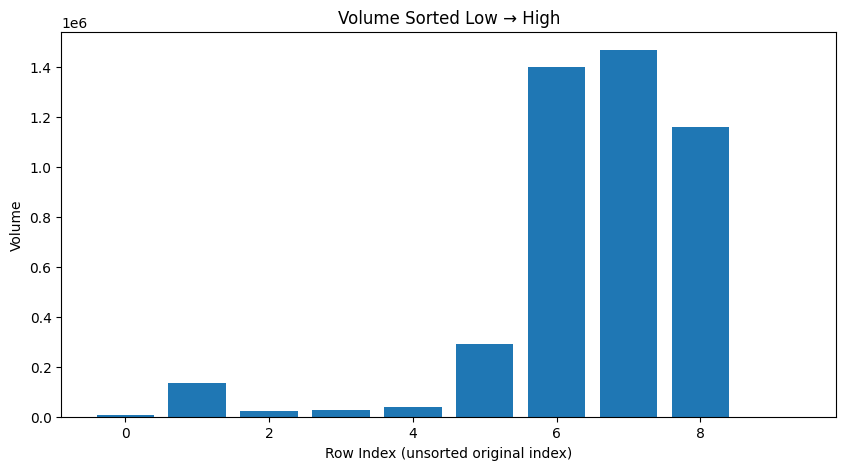

In [ ]:
test03 = test01

test03["volume_fp"] = pd.to_numeric(test03["volume_fp"])
test03_sorted = test03.sort_values("volume_fp", ascending=True)

plt.figure(figsize=(10, 5))
plt.bar(test03_sorted.index, test03_sorted["volume_fp"])

plt.xlabel("Row Index (unsorted original index)")
plt.ylabel("Volume")
plt.title("Volume Sorted Low → High")

plt.show()



Total count of buy and sell transactions. Again, should always be increasing until contract closes.

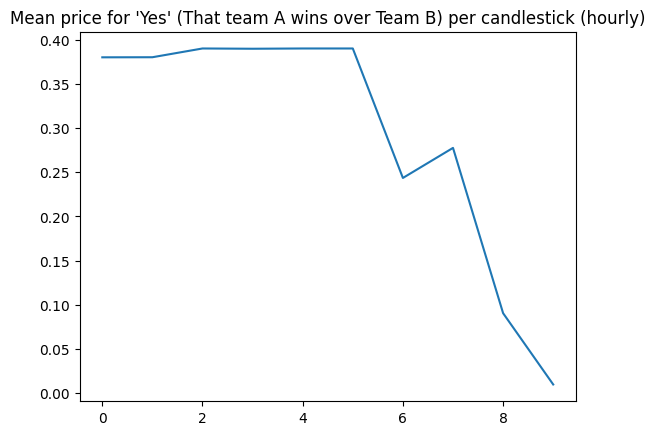

In [145]:
plt.plot(test01.index, test01['mean_dollars'])
plt.title("Mean price for 'Yes' (That team A wins over Team B) per candlestick (hourly)")
plt.show()

The data for this example is specifically for the Dodgers vs. Giants on May 14, 2026. The contract was if the Giants would beat the Dodgers. The Dodgers has the superior record going into the game, so the Giants were already the underdogs. The Dodgers scored the 2 runs in the first 2 innings, then the Giants scored 2 in the 5th, then the Dodgers scored 3 in the 6th, and the final score was 5-2 Dodgers. This is reflected in the mean price of a 'Yes' contract for the Giants winning. We see a drop as the Dodgers score early, then a slight uptick when the Giants tie the game, before another steep fall as the Dodgers take the lead the next inning, and this remains until the game ends.